# Environment Setup
## Library Imports

In [1]:
import os
import glob
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torchaudio
import librosa
import librosa.display
import matplotlib.pyplot as plt
import random
import timm
import wandb
from kaggle_secrets import UserSecretsClient
from torchvision.models import resnet18
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings("ignore")

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

## Weights and Biases Configuration Setup

In [2]:
user_secrets = UserSecretsClient()

os.environ["WANDB_API_KEY"] = user_secrets.get_secret("WANDB_API_KEY")

os.environ["WANDB_DISABLE_SERVICE"] = "true"
os.environ["WANDB_START_METHOD"] = "thread"

try:
    wandb.login()
    WANDB_MODE = "online"
except:
    WANDB_MODE = "disabled" 
    print("Running in offline mode - WandB logging disabled")

WANDB_PROJECT = "23f3003805-t12026"

wandb: WARNING `start_method` is deprecated and will be removed in a future version of wandb. This setting is currently non-functional and safely ignored.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


## Device Configuration

In [3]:
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Tesla T4


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data Configuration
## Loading data

In [5]:
DATA_DIR = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"


STEMS_DIR = f"{DATA_DIR}/genres_stems"
MASHUPS_DIR = f"{DATA_DIR}/mashups"
ESC50_DIR = f"{DATA_DIR}/ESC-50-master/audio"

TEST_CSV = f"{DATA_DIR}/test.csv"
SUBMISSION_CSV = f"{DATA_DIR}/sample_submission.csv"

## Genre Label Mapping

In [6]:
GENRES = sorted(os.listdir(STEMS_DIR))
GENRE_TO_IDX = {g:i for i,g in enumerate(GENRES)}
# jazz=0 rock=1 ...

IDX_TO_GENRE = {i:g for g,i in GENRE_TO_IDX.items()}

print(GENRES)

['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [7]:
SR = 22050
CROP_SIZE = SR * 6
N_MELS = 128
N_FFT = 2048    
HOP_LENGTH = 256     
F_MIN = 20
F_MAX = 11025   
TOP_DB = 80
BATCH_SIZE = 64
EPOCHS = 40

# Dataset Construction
## Stem Metadata Creation

In [8]:
records = []
# stores path to 4 stems for all songs

for genre in GENRES:
    genre_path = os.path.join(STEMS_DIR, genre)

    for song in os.listdir(genre_path):

        song_path = os.path.join(genre_path, song)

        stems = {
            "bass": os.path.join(song_path,"bass.wav"),
            "drums": os.path.join(song_path,"drums.wav"),
            "other": os.path.join(song_path,"other.wav"),
            "vocals": os.path.join(song_path,"vocals.wav")
        }

        records.append({
            "genre":genre,
            "genre_id":GENRE_TO_IDX[genre],
            "stems":stems
        })

df = pd.DataFrame(records)
df.head()

,genre,genre_id,stems
0,blues,0,{'bass': '/kaggle/input/jan-2026-dl-gen-ai-pro...
1,blues,0,{'bass': '/kaggle/input/jan-2026-dl-gen-ai-pro...
2,blues,0,{'bass': '/kaggle/input/jan-2026-dl-gen-ai-pro...
3,blues,0,{'bass': '/kaggle/input/jan-2026-dl-gen-ai-pro...
4,blues,0,{'bass': '/kaggle/input/jan-2026-dl-gen-ai-pro...


# Exploratory Data Analysis Part 1

In [9]:
print("Total samples:", len(df))
print("Total genres:", len(GENRES))
print("Genres:", GENRES)

df.head()

Total samples: 1000
Total genres: 10
Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


,genre,genre_id,stems
0,blues,0,{'bass': '/kaggle/input/jan-2026-dl-gen-ai-pro...
1,blues,0,{'bass': '/kaggle/input/jan-2026-dl-gen-ai-pro...
2,blues,0,{'bass': '/kaggle/input/jan-2026-dl-gen-ai-pro...
3,blues,0,{'bass': '/kaggle/input/jan-2026-dl-gen-ai-pro...
4,blues,0,{'bass': '/kaggle/input/jan-2026-dl-gen-ai-pro...


## Genre Distribution

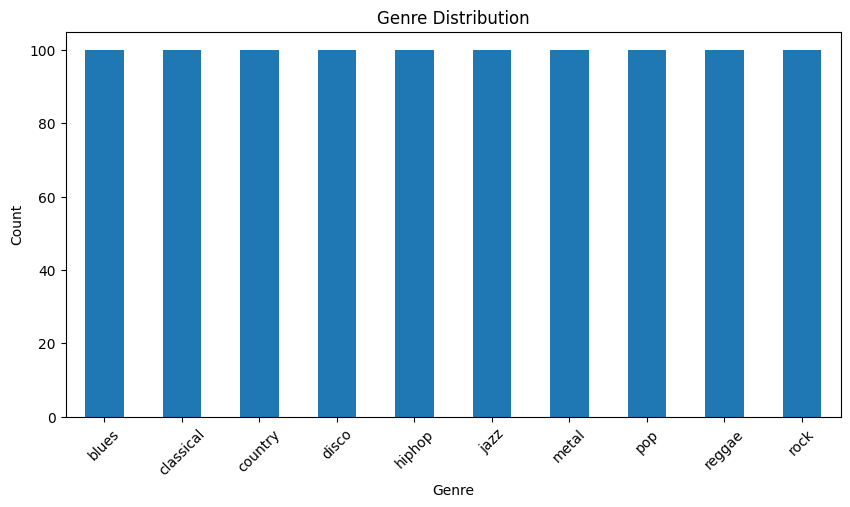

genre
blues        100
classical    100
country      100
disco        100
hiphop       100
jazz         100
metal        100
pop          100
reggae       100
rock         100
Name: count, dtype: int64


In [10]:
genre_counts = df['genre'].value_counts()

#helps detect class imbalance

plt.figure(figsize=(10,5))
genre_counts.plot(kind='bar')
plt.title("Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

print(genre_counts)

## File Size Analysis

In [11]:
LESS_THAN_4KB = 0
LESS_THAN_5MB = 0

SIZE_4KB = 4 * 1024
SIZE_5MB = 5 * 1024 * 1024

for genre in GENRES:
    genre_path = os.path.join(STEMS_DIR, genre)

    for song in os.listdir(genre_path):
        song_path = os.path.join(genre_path, song)

        for stem in ["bass.wav","drums.wav","other.wav","vocals.wav"]:
            stem_path = os.path.join(song_path, stem)

            if not os.path.exists(stem_path):
                continue

            size = os.path.getsize(stem_path)

            if size < SIZE_4KB:
                LESS_THAN_4KB += 1

            if size < SIZE_5MB:
                LESS_THAN_5MB += 1

print("Files < 4KB:", LESS_THAN_4KB)
print("Files < 5MB:", LESS_THAN_5MB)

Files < 4KB: 0
Files < 5MB: 0


## ESC-50 Noise Dataset

In [12]:
noise_files = []
# stores noise

for f in os.listdir(ESC50_DIR):
    if f.endswith(".wav"):
        noise_files.append(os.path.join(ESC50_DIR,f))

print("Noise files:",len(noise_files))

Noise files: 2000


# Data Preprocessing and Feature Engineering
## Audio Processing Functions
### Audio Loading Function

In [13]:
def load_audio(path, sr=22050):

    y, _ = librosa.load(path, sr=sr)

    return y

### Synthetic Mashup Generator

In [14]:
genre_groups = {g: df[df.genre == g] for g in GENRES}

def synthetic_mashup(genre):
    # takes 4 random songs of same genre nad mixes stems
    
    songs = genre_groups[genre].sample(4)

    bass = load_audio(songs.iloc[0].stems["bass"])
    drums = load_audio(songs.iloc[1].stems["drums"])
    vocals = load_audio(songs.iloc[2].stems["vocals"])
    other = load_audio(songs.iloc[3].stems["other"])

    min_len = min(len(bass), len(drums), len(vocals), len(other))
    # align to shortest length

    bass = bass[:min_len]
    drums = drums[:min_len]
    vocals = vocals[:min_len]
    other = other[:min_len]

    w = np.random.uniform(0.5, 1.5, 4)
    # ransdom weight for mixing

    mix = (
        w[0]*bass +
        w[1]*drums +
        w[2]*vocals +
        w[3]*other
    )

    mix = mix / (np.max(np.abs(mix)) + 1e-6)
    # normalize

    return mix

## Silence Analysis

In [15]:
# defines how is silence spread out across dtaa
def compute_silence(y, threshold=0.01):
    silent = np.where(np.abs(y) < threshold, 1, 0)
    silence_ratio = np.mean(silent)
    return silence_ratio

silence_data = []

for i,row in tqdm(df.iterrows(), total=len(df)):
    y = synthetic_mashup(row.genre)
    
    silence_ratio = compute_silence(y)
    
    silence_data.append({
        "Genre": row.genre,
        "Silence_Ratio": silence_ratio
    })

df_silence = pd.DataFrame(silence_data)

df_silence.head()

100%|██████████| 1000/1000 [06:21<00:00,  2.62it/s]


,Genre,Silence_Ratio
0,blues,0.062328
1,blues,0.080283
2,blues,0.217602
3,blues,0.109034
4,blues,0.072625


## Silence Distribution

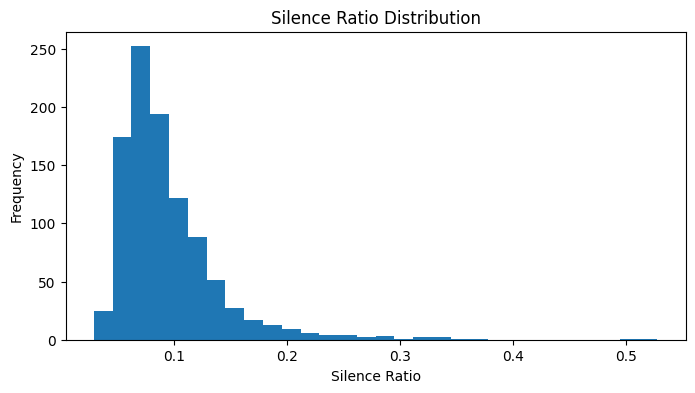

Average Silence: 0.09419992854195226


In [16]:
plt.figure(figsize=(8,4))
plt.hist(df_silence["Silence_Ratio"], bins=30)
plt.title("Silence Ratio Distribution")
plt.xlabel("Silence Ratio")
plt.ylabel("Frequency")
plt.show()

print("Average Silence:", df_silence["Silence_Ratio"].mean())

## Audio Data Augmentation Techniques
### Noise Injection

In [17]:
import torchaudio.transforms as T

spec_augment = torch.nn.Sequential(
    T.FrequencyMasking(freq_mask_param=15),
    # blocks certian freq channels
    T.TimeMasking(time_mask_param=35)
    # blocks time steps
)

In [18]:
def add_noise(signal, snr_db=10):
    # adds random noise 
    noise_path = random.choice(noise_files)
    noise = load_audio(noise_path)

    if len(noise) < len(signal):
        noise = np.tile(noise, len(signal)//len(noise)+1)

    noise = noise[:len(signal)]

    signal_power = np.mean(signal**2)
    noise_power = np.mean(noise**2)

    factor = np.sqrt(signal_power/(10**(snr_db/10)*noise_power))
    # checks power ratio for addingnoice at correct decibel
    noisy = signal + factor*noise

    return noisy

### Time Stretching and Padding

In [19]:
def augment_audio(y, target_len=None):
# stretching for avoiding overfiiting
    if random.random() < 0.5:
        rate = random.uniform(0.9, 1.1)
        y = librosa.effects.time_stretch(y, rate=rate)

    if random.random() < 0.5:
        y = add_noise(y, snr_db=random.randint(5, 20))

    if target_len is not None:
    # standardize length
        if len(y) > target_len:
            y = y[:target_len]

        else:
            pad = target_len - len(y)
            y = np.pad(y, (0, pad))

    return y

### Random Audio Cropping

In [20]:
def random_crop(y, crop_size):
# randomly crops audio to specific length
    if len(y) <= crop_size:
        return np.pad(y, (0, crop_size - len(y)))

    start = random.randint(0, len(y) - crop_size)

    return y[start:start + crop_size]

# Exploratory Data Analysis Part 2
## Sample Waveform Visualization

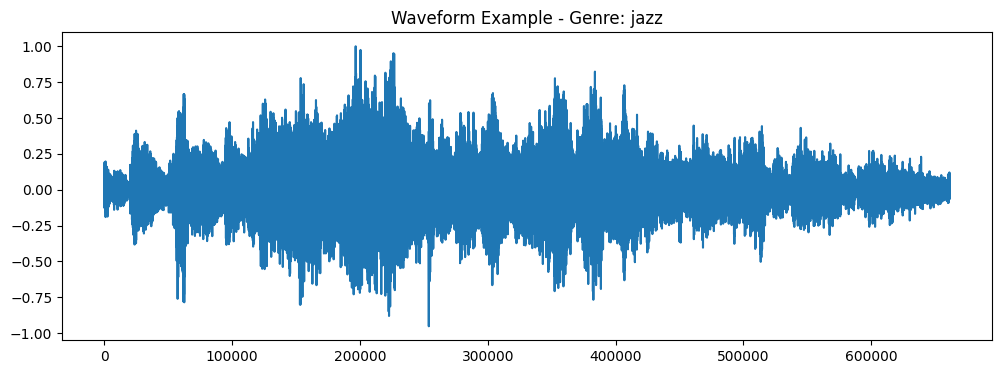

In [21]:
# amplitude vs graph
# peaks = loud sound flat=silence 
sample_row = df.sample(1).iloc[0]

audio = synthetic_mashup(sample_row.genre)

plt.figure(figsize=(12,4))
plt.plot(audio)
plt.title(f"Waveform Example - Genre: {sample_row.genre}")
plt.show()

## Spectrogram Visualization

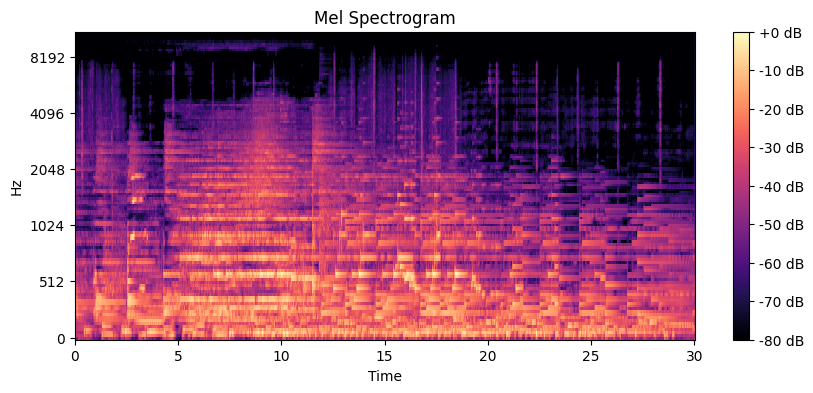

In [22]:
# audio into freq vs time
# cnn uses spectro
# bright=strong freq dark=weak
S = librosa.feature.melspectrogram(y=audio, sr=22050)
S_db = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(10,4))
librosa.display.specshow(S_db, sr=22050, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectrogram")
plt.show()

## Audio Length Analysis

100%|██████████| 1000/1000 [04:23<00:00,  3.79it/s]


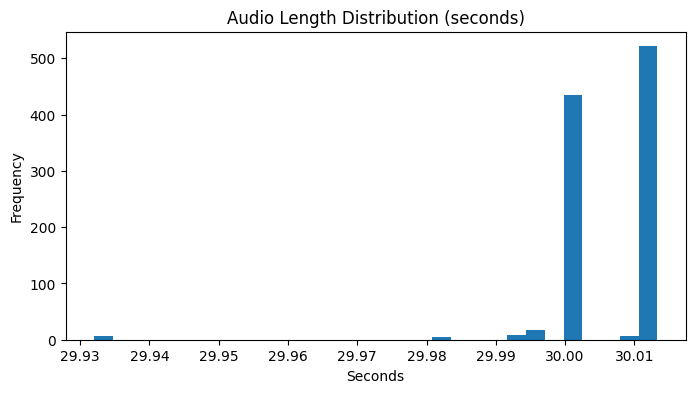

Min length: 29.931972789115648
Max length: 30.013333333333332
Mean length: 30.00635909297052


In [23]:
lengths = []
# audio files can have diff length

for i,row in tqdm(df.iterrows(), total=len(df)):
    y = synthetic_mashup(row.genre)
    lengths.append(len(y)/22050)  # seconds

plt.figure(figsize=(8,4))
plt.hist(lengths, bins=30)
plt.title("Audio Length Distribution (seconds)")
plt.xlabel("Seconds")
plt.ylabel("Frequency")
plt.show()

print("Min length:", np.min(lengths))
print("Max length:", np.max(lengths))
print("Mean length:", np.mean(lengths))

# Dataset & DataLoader
## Custom PyTorch Dataset

In [24]:
class StemDataset(Dataset):

    def __init__(self, df, sr=22050):
        self.df = df
        self.sr = sr

    def __len__(self):
        return len(self.df)

    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        y = synthetic_mashup(row.genre)
        
        y = random_crop(y, 22050 * 6)
        # cuts random 6 sec segment
        y = augment_audio(y, 22050 * 6)
        # add noise for shifting pitch 
        
        # y = y / (np.max(np.abs(y)) + 1e-6)
        y = torch.tensor(y).float().unsqueeze(0)
        label = row.genre_id
        return y, label

## Custom Collate Function

In [25]:
def collate_fn(batch):
    waves = [b[0] for b in batch]
    labels = [b[1] for b in batch]
    # pads the waves and 
    max_len = max([w.shape[1] for w in waves])
    padded = []
    for w in waves:
        pad = max_len - w.shape[1]
        padded.append(nn.functional.pad(w,(0,pad)))

    return torch.stack(padded), torch.tensor(labels)

## Train-Validation Split

In [26]:
train_df, val_df = train_test_split(
    df,
    test_size=0.1,
    stratify=df.genre,
    random_state=42
)

## DataLoaders

In [27]:
train_ds = StemDataset(train_df)
val_ds = StemDataset(val_df)

train_loader = DataLoader(
    train_ds,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=64,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

# Spectrogram Feature Transformation
## Mel Spectrogram Conversion

In [28]:
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=22050,
    n_fft=1024,
    hop_length=256,
    n_mels=128,
    f_min=20,
    f_max=11025
)
# converts raw audio into mel frequency

# Model Architecture

## CNN

In [29]:
class SimpleCNN(nn.Module):

    def __init__(self):
        super().__init__()
        self.mel = mel_transform
        self.net = nn.Sequential(

            nn.Conv2d(1,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d(1)
            # squashes entire 2d data to spectrogram into singel vector
        )
        self.fc = nn.Linear(128,len(GENRES))

    
    def forward(self,x):
        x = self.mel(x)
        x = torch.log(x + 1e-6)
        # convert amplitudes to decibels

        x = self.net(x)
        x = x.view(x.size(0),-1)
        return self.fc(x)

## CRNN

In [30]:
class CRNN(nn.Module):

    def __init__(self):
        super().__init__()
        self.mel = mel_transform
        self.cnn = nn.Sequential(
# filterskernal slides over -> detects patterns-> non linearrity-> dim reducion
            nn.Conv2d(1,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # extracts local features 
        
        self.gru = nn.GRU(
            input_size=128,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )
        # remembers what happended in beiginning 
        self.fc = nn.Linear(256,len(GENRES))

    
    def forward(self,x):
        x = self.mel(x)
        x = torch.log(x+1e-6)

        x = self.cnn(x)
        x = x.mean(dim=2)
        x = x.permute(0,2,1)
        x,_ = self.gru(x)
        x = x.mean(dim=1)

        return self.fc(x)

## EfficientNet

In [31]:
class EfficientNetAudio(nn.Module):

    def __init__(self):
        super().__init__()

        self.mel = mel_transform
        self.freq_mask = torchaudio.transforms.FrequencyMasking(24)
        self.time_mask = torchaudio.transforms.TimeMasking(40)
# compound scaling - balcnes width depth resolution
# pretrained= model already knows tosee shapes n textures
# inchnas = accepts singlechannel instead of rgb
        self.backbone = timm.create_model(
            "tf_efficientnet_b0",
            pretrained=True,
            in_chans=1,
            num_classes=len(GENRES)
        )

    
    def forward(self,x):
        x = self.mel(x)
        x = torch.log(x+1e-6)

        x = (x - x.mean(dim=(2,3),keepdim=True)) / (x.std(dim=(2,3),keepdim=True)+1e-6)

        if self.training:
            x = self.freq_mask(x)
            x = self.time_mask(x)

        return self.backbone(x)

## Final EfficientNet Model

In [32]:
class AudioClassifier(nn.Module):

    def __init__(self):
        super().__init__()
        self.mel = mel_transform
        self.freq_mask = torchaudio.transforms.FrequencyMasking(48)
        self.time_mask = torchaudio.transforms.TimeMasking(96)

        self.backbone = timm.create_model(
            "tf_efficientnet_b0",
            pretrained=True,
            in_chans=1,
            num_classes=len(GENRES)
        )

    def forward(self,x):
        x = self.mel(x)
        x = torch.log(x + 1e-6)

        x = (x - x.mean(dim=(2,3), keepdim=True)) / (x.std(dim=(2,3), keepdim=True) + 1e-6)

        if self.training:
            if random.random() < 0.5:
                x = self.freq_mask(x)
            if random.random() < 0.5:
                x = self.time_mask(x)

        return self.backbone(x)

# Model Training

In [33]:
def evaluate_model(model):
    model.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            preds_all.extend(model(x).argmax(1).cpu().numpy())
            labels_all.extend(y.numpy())
    f1  = f1_score(labels_all, preds_all, average="macro")
    acc = accuracy_score(labels_all, preds_all)
    return f1, acc

## Simple CNN Training

In [34]:
run=wandb.init(
    project=WANDB_PROJECT,
    name="simple_cnn",
    reinit="finish_previous",
    config={
        "model":"SimpleCNN",
        "optimizer":"Adam",
        "lr":1e-3,
        "epochs":10,
        "batch_size":BATCH_SIZE
    }
)

wandb: setting up run 54xwi7ze
wandb: Tracking run with wandb version 0.22.2
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260405_145238-54xwi7ze
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run simple_cnn
wandb: ⭐️ View project at https://wandb.ai/23f3003805-dl-genai-project/23f3003805-t12026
wandb: 🚀 View run at https://wandb.ai/23f3003805-dl-genai-project/23f3003805-t12026/runs/54xwi7ze


In [35]:
cnn_model = SimpleCNN().to(device)
optimizer = torch.optim.Adam(cnn_model.parameters(),lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(10):
    cnn_model.train()
    total_loss = 0

    for x,y in tqdm(train_loader, desc=f"CNN epoch {epoch}"):
        x,y = x.to(device),y.to(device)
        optimizer.zero_grad()     
        preds = cnn_model(x)
        loss = criterion(preds,y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    avg_loss = total_loss/len(train_loader)
    run.log({
        "epoch":epoch,
        "train_loss":avg_loss
    })
    print("Epoch",epoch,"Loss",avg_loss)

CNN epoch 0: 100%|██████████| 15/15 [01:59<00:00,  7.98s/it]


Epoch 0 Loss 2.128122862180074


CNN epoch 1: 100%|██████████| 15/15 [01:46<00:00,  7.11s/it]


Epoch 1 Loss 1.8985703627268473


CNN epoch 2: 100%|██████████| 15/15 [01:40<00:00,  6.70s/it]


...

Epoch 7 Loss 1.59170241355896


CNN epoch 8: 100%|██████████| 15/15 [01:37<00:00,  6.52s/it]


Epoch 8 Loss 1.536550760269165


CNN epoch 9: 100%|██████████| 15/15 [01:37<00:00,  6.48s/it]

Epoch 9 Loss 1.5705028136571249


In [36]:
f1, acc = evaluate_model(cnn_model)

run.log({
    "epoch": epoch,
    "train_loss": avg_loss,
    "val_f1": f1,
    "val_accuracy": acc
})

print("CNN F1:", f1)
print("CNN Accuracy:", acc)

run.finish()

wandb: updating run metadata


CNN F1: 0.45578075623842207
CNN Accuracy: 0.5


wandb: 
wandb: Run history:
wandb:        epoch ▁▂▃▃▄▅▆▆▇██
wandb:   train_loss █▅▅▃▄▃▂▂▁▁▁
wandb: val_accuracy ▁
wandb:       val_f1 ▁
wandb: 
wandb: Run summary:
wandb:        epoch 9
wandb:   train_loss 1.5705
wandb: val_accuracy 0.5
wandb:       val_f1 0.45578
wandb: 
wandb: 🚀 View run simple_cnn at: https://wandb.ai/23f3003805-dl-genai-project/23f3003805-t12026/runs/54xwi7ze
wandb: ⭐️ View project at: https://wandb.ai/23f3003805-dl-genai-project/23f3003805-t12026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260405_145238-54xwi7ze/logs


## CRNN Training

In [37]:
run=wandb.init(
    project=WANDB_PROJECT,
    name="crnn_model",
    reinit="finish_previous",
    config={
        "model":"CRNN",
        "optimizer":"Adam",
        "lr":3e-4,
        "epochs":12
    }
)

wandb: Tracking run with wandb version 0.22.2
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260405_150954-mh3ujt5x
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run crnn_model
wandb: ⭐️ View project at https://wandb.ai/23f3003805-dl-genai-project/23f3003805-t12026
wandb: 🚀 View run at https://wandb.ai/23f3003805-dl-genai-project/23f3003805-t12026/runs/mh3ujt5x


In [38]:
crnn_model = CRNN().to(device)
optimizer = torch.optim.Adam(crnn_model.parameters(),lr=3e-4)
criterion = nn.CrossEntropyLoss()

for epoch in range(12):
    crnn_model.train()
    total_loss = 0

    for x,y in tqdm(train_loader, desc=f"CRNN epoch {epoch}"):
        x,y = x.to(device),y.to(device)
        optimizer.zero_grad()
        preds = crnn_model(x)
        loss = criterion(preds,y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    run.log({
        "epoch":epoch,
        "train_loss":total_loss/len(train_loader),
        "learning_rate":optimizer.param_groups[0]['lr']
    })

    print("Epoch",epoch,"Loss",total_loss/len(train_loader))

CRNN epoch 0: 100%|██████████| 15/15 [01:38<00:00,  6.54s/it]


Epoch 0 Loss 2.2585340181986493


CRNN epoch 1: 100%|██████████| 15/15 [01:37<00:00,  6.49s/it]


Epoch 1 Loss 2.1812270641326905


CRNN epoch 2: 100%|██████████| 15/15 [01:37<00:00,  6.49s/it]


...

Epoch 9 Loss 1.7056458791097004


CRNN epoch 10: 100%|██████████| 15/15 [01:35<00:00,  6.36s/it]


Epoch 10 Loss 1.7375157753626504


CRNN epoch 11: 100%|██████████| 15/15 [01:36<00:00,  6.40s/it]

Epoch 11 Loss 1.6438947439193725


In [39]:
f1, acc = evaluate_model(crnn_model)

run.log({
    "F1_score": f1,
    "accuracy": acc
})

print("CRNN F1:", f1)
print("CRNN Accuracy:", acc)

run.finish()

wandb: updating run metadata


CRNN F1: 0.32439117692206937
CRNN Accuracy: 0.36


wandb: 
wandb: Run history:
wandb:      F1_score ▁
wandb:      accuracy ▁
wandb:         epoch ▁▂▂▃▄▄▅▅▆▇▇█
wandb: learning_rate ▁▁▁▁▁▁▁▁▁▁▁▁
wandb:    train_loss █▇▇▇▆▅▄▂▂▂▂▁
wandb: 
wandb: Run summary:
wandb:      F1_score 0.32439
wandb:      accuracy 0.36
wandb:         epoch 11
wandb: learning_rate 0.0003
wandb:    train_loss 1.64389
wandb: 
wandb: 🚀 View run crnn_model at: https://wandb.ai/23f3003805-dl-genai-project/23f3003805-t12026/runs/mh3ujt5x
wandb: ⭐️ View project at: https://wandb.ai/23f3003805-dl-genai-project/23f3003805-t12026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260405_150954-mh3ujt5x/logs


## EffiecientNet Training

In [40]:
run=wandb.init(
    project=WANDB_PROJECT,
    name="efficientnet_b0_fixed",
    reinit="finish_previous",
    config={
        "model":"EfficientNetB0",
        "epochs":30,
        "lr": 3e-4
    }
)

wandb: Tracking run with wandb version 0.22.2
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260405_152928-q9ngkv1h
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run efficientnet_b0_fixed
wandb: ⭐️ View project at https://wandb.ai/23f3003805-dl-genai-project/23f3003805-t12026
wandb: 🚀 View run at https://wandb.ai/23f3003805-dl-genai-project/23f3003805-t12026/runs/q9ngkv1h


In [41]:
effnet_model = EfficientNetAudio().to(device)
optimizer = torch.optim.AdamW(effnet_model.parameters(),lr=3e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=30)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

for epoch in range(30):
    effnet_model.train()
    total_loss = 0

    for x,y in tqdm(train_loader, desc=f"EffNet epoch {epoch}"):
        x,y = x.to(device),y.to(device)
        optimizer.zero_grad()
        preds = effnet_model(x)
        loss = criterion(preds,y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    run.log({
        "epoch": epoch,
        "train_loss": avg_loss,
        "lr": optimizer.param_groups[0]["lr"]
    })
    scheduler.step()

    print("Epoch",epoch,"Loss",total_loss/len(train_loader))

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

EffNet epoch 0: 100%|██████████| 15/15 [01:37<00:00,  6.49s/it]


Epoch 0 Loss 2.171059815088908


EffNet epoch 1: 100%|██████████| 15/15 [01:36<00:00,  6.42s/it]


Epoch 1 Loss 1.640607492129008


...

Epoch 27 Loss 1.0019633650779725


EffNet epoch 28: 100%|██████████| 15/15 [01:41<00:00,  6.79s/it]


Epoch 28 Loss 1.0928766846656799


EffNet epoch 29: 100%|██████████| 15/15 [01:39<00:00,  6.66s/it]

Epoch 29 Loss 0.9998655676841736


In [42]:
f1, acc = evaluate_model(effnet_model)

run.log({
    "F1_score": f1,
    "accuracy": acc
})
run.finish()

wandb: updating run metadata
wandb: 
wandb: Run history:
wandb:   F1_score ▁
wandb:   accuracy ▁
wandb:      epoch ▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
wandb:         lr ██████▇▇▇▇▆▆▆▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁▁▁
wandb: train_loss █▅▄▄▃▃▂▃▃▂▂▂▂▂▁▂▂▁▁▂▂▂▁▂▁▁▁▁▂▁
wandb: 
wandb: Run summary:
wandb:   F1_score 0.82525
wandb:   accuracy 0.83
wandb:      epoch 29
wandb:         lr 0.0
wandb: train_loss 0.99987
wandb: 
wandb: 🚀 View run efficientnet_b0_fixed at: https://wandb.ai/23f3003805-dl-genai-project/23f3003805-t12026/runs/q9ngkv1h
wandb: ⭐️ View project at: https://wandb.ai/23f3003805-dl-genai-project/23f3003805-t12026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260405_152928-q9ngkv1h/logs


## Final Model AudioClassifier Training

In [43]:
run = wandb.init(
    project=WANDB_PROJECT,
    name="efficientnet_final_augmented",
    reinit="finish_previous",
    config={
        "model": "AudioClassifier",
        "augmentation": "Mixup + SpecAugment + T-Stretch",
        "epochs": EPOCHS,
        "lr": 3e-4
    }
)

wandb: Tracking run with wandb version 0.22.2
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260405_161902-o426vwke
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run efficientnet_final_augmented
wandb: ⭐️ View project at https://wandb.ai/23f3003805-dl-genai-project/23f3003805-t12026
wandb: 🚀 View run at https://wandb.ai/23f3003805-dl-genai-project/23f3003805-t12026/runs/o426vwke


In [44]:
effnet_aug_model = AudioClassifier().to(device)
optimizer = torch.optim.AdamW(effnet_aug_model.parameters(), lr=3e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)
# criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
criterion = nn.CrossEntropyLoss()


for epoch in range(EPOCHS):
    effnet_aug_model.train()
    total_loss = 0

    for x,y in tqdm(train_loader):

        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        lam = np.random.beta(0.4, 0.4)
        index = torch.randperm(x.size(0)).to(device)
        mixed_x = lam * x + (1 - lam) * x[index]
        
        y_a, y_b = y, y[index]
        preds = effnet_aug_model(mixed_x)
        
        loss = lam * criterion(preds, y_a) + (1 - lam) * criterion(preds, y_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(effnet_aug_model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
    scheduler.step()
    
    run.log({"epoch": epoch, "loss": total_loss/len(train_loader)})

    print("Epoch",epoch,"Loss",total_loss/len(train_loader))

100%|██████████| 15/15 [01:41<00:00,  6.74s/it]


Epoch 0 Loss 2.200092895825704


100%|██████████| 15/15 [01:40<00:00,  6.71s/it]


Epoch 1 Loss 1.8326102018356323


100%|██████████| 15/15 [01:39<00:00,  6.61s/it]


...

Epoch 37 Loss 1.1479220469792684


100%|██████████| 15/15 [01:38<00:00,  6.58s/it]


Epoch 38 Loss 1.3293388724327087


100%|██████████| 15/15 [01:45<00:00,  7.04s/it]

Epoch 39 Loss 1.0738997399806975


In [45]:
effnet_aug_model.eval()
correct, total = 0, 0
with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(device), y.to(device)
        correct += (effnet_aug_model(x).argmax(1) == y).sum().item()
        total   += len(y)
val_acc = correct / total
run.log({"final_val_accuracy": val_acc})
print(f"Final model  |  Val accuracy: {val_acc:.4f}")
run.finish()

wandb: updating run metadata


Final model  |  Val accuracy: 0.8300


wandb: 
wandb: Run history:
wandb:              epoch ▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
wandb: final_val_accuracy ▁
wandb:               loss █▆▅▄▄▃▄▃▂▂▃▃▄▃▄▂▂▃▂▃▃▂▁▂▂▂▃▂▁▂▂▁▁▃▂▂▃▂▃▂
wandb: 
wandb: Run summary:
wandb:              epoch 39
wandb: final_val_accuracy 0.83
wandb:               loss 1.0739
wandb: 
wandb: 🚀 View run efficientnet_final_augmented at: https://wandb.ai/23f3003805-dl-genai-project/23f3003805-t12026/runs/o426vwke
wandb: ⭐️ View project at: https://wandb.ai/23f3003805-dl-genai-project/23f3003805-t12026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260405_161902-o426vwke/logs


# Model Deployment

In [46]:
torch.save(cnn_model.state_dict(), "cnn.pth")
torch.save(crnn_model.state_dict(), "crnn.pth")
torch.save(effnet_model.state_dict(), "effnet.pth")
torch.save(effnet_aug_model.state_dict(), "effnet_aug.pth")

In [47]:
import json

with open("label_map.json", "w") as f:
    json.dump(IDX_TO_GENRE, f)

# Inference and Ensemble Prediction

## Test Data Prep

In [48]:
class MashupDataset(Dataset):

    def __init__(self,test_df):
        self.df = test_df

    def __len__(self):
        return len(self.df)

    def __getitem__(self,idx):
        row = self.df.iloc[idx]
        path = os.path.join(DATA_DIR,row.filename)
        y,_ = librosa.load(path,sr=22050)
        y = torch.tensor(y).float().unsqueeze(0)

        return y,row.id

## Test DAta Loader

In [49]:
test_df = pd.read_csv(TEST_CSV)

test_ds = MashupDataset(test_df)

test_loader = DataLoader(
    test_ds,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=lambda b: collate_fn([(x,0) for x,_ in b])
)

## Ensemble Function

In [50]:
def predict_audio(audio):

    crop_size = 22050 * 6
    crops = []

    step = crop_size // 4
    for start in range(0, max(1, len(audio) - crop_size + 1), step):
        crops.append(audio[start:start+crop_size])

    if len(crops) == 0:
        crops.append(random_crop(audio,crop_size))

    preds = []
    
    for crop in crops:
        x = torch.tensor(crop).float().unsqueeze(0).unsqueeze(0).to(device)

        with torch.no_grad():
            p1 = torch.softmax(cnn_model(x),1)
            p2 = torch.softmax(crnn_model(x),1)
            p3 = torch.softmax(effnet_model(x),1)
            p4 = torch.softmax(effnet_aug_model(x),1)
            p = (
                0.15*p1 +
                0.25*p2 +
                0.35*p3 +
                0.25*p4
            )
        preds.append(p.cpu().numpy())
    preds = np.mean(preds,axis=0)

    return preds.argmax()

## Run Inference

In [51]:
ensemble_run = wandb.init(
    project=WANDB_PROJECT, 
    name="final_ensemble_submission",
    reinit=True,
)

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.
wandb: Tracking run with wandb version 0.22.2
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260405_172533-u5m1hbdj
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run final_ensemble_submission
wandb: ⭐️ View project at https://wandb.ai/23f3003805-dl-genai-project/23f3003805-t12026
wandb: 🚀 View run at https://wandb.ai/23f3003805-dl-genai-project/23f3003805-t12026/runs/u5m1hbdj


## Generating Predictions

In [52]:
cnn_model.eval()
crnn_model.eval()
effnet_model.eval()
effnet_aug_model.eval()

test_df = pd.read_csv(TEST_CSV)

predictions = []

for i,row in tqdm(test_df.iterrows(), total=len(test_df)):
    path = os.path.join(DATA_DIR, row.filename)
    y,_ = librosa.load(path, sr=SR)
    pred = predict_audio(y)
    predictions.append(pred)
    
    if i % 100 == 0:
        ensemble_run.log({"progress": i / len(test_df)})

100%|██████████| 3020/3020 [18:08<00:00,  2.78it/s]


# Submission

In [53]:
submission = pd.read_csv(SUBMISSION_CSV)
submission["genre"] = [IDX_TO_GENRE[p] for p in predictions]
submission.head()

,id,genre
0,1,pop
1,2,classical
2,3,disco
3,4,metal
4,5,country


In [54]:
submission.to_csv("submission.csv",index=False)
ensemble_run.finish()
print("submission.csv saved.")

wandb: updating run metadata
wandb: 
wandb: Run history:
wandb: progress ▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇███
wandb: 
wandb: Run summary:
wandb: progress 0.99338
wandb: 
wandb: 🚀 View run final_ensemble_submission at: https://wandb.ai/23f3003805-dl-genai-project/23f3003805-t12026/runs/u5m1hbdj
wandb: ⭐️ View project at: https://wandb.ai/23f3003805-dl-genai-project/23f3003805-t12026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260405_172533-u5m1hbdj/logs


submission.csv saved.
